In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re
import cv2
import wfdb
from scipy.signal import butter, filtfilt

Part A: Tabular Data (Pima Indians Diabetes)

In [4]:
# 1. Load Dataset
df_tabular = pd.read_csv('diabetes.csv')
print("Initial Data Shape:", df_tabular.shape)

Initial Data Shape: (768, 9)


In [5]:
# 2. Healthcare-Specific Cleaning: Handling Implausible Values (0s in biological metrics)
implausible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_tabular[implausible_cols] = df_tabular[implausible_cols].replace(0, np.nan)
df_tabular[implausible_cols] = df_tabular[implausible_cols].fillna(df_tabular[implausible_cols].median())


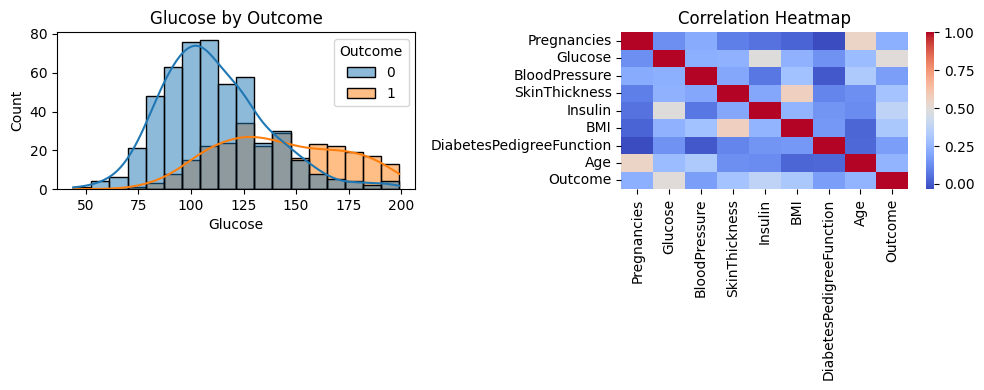

In [6]:
# 3. EDA (Exploratory Data Analysis)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=df_tabular, x='Glucose', hue='Outcome', kde=True)
plt.title("Glucose by Outcome")

plt.subplot(1, 2, 2)
sns.heatmap(df_tabular.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
# 4. Statistical Tests
print("Statistical Analysis")

# A) T-test: Glucose differences between outcomes
diabetic = df_tabular[df_tabular['Outcome'] == 1]['Glucose']
non_diabetic = df_tabular[df_tabular['Outcome'] == 0]['Glucose']
t_stat, p_val_t = stats.ttest_ind(diabetic, non_diabetic)
print(f"T-test (Glucose): p-value = {p_val_t:.2e}")

# B) Chi-Square Test: Age category vs Outcome
df_tabular['Age_Group'] = pd.cut(df_tabular['Age'], bins=[20, 30, 45, 100], labels=['Young', 'Middle', 'Senior'])
contingency_table = pd.crosstab(df_tabular['Age_Group'], df_tabular['Outcome'])
chi2, p_val_chi, _, _ = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Test (Age Group vs Outcome): p-value = {p_val_chi:.2e}")

# C) ANOVA: BMI across Age Groups
young = df_tabular[df_tabular['Age_Group'] == 'Young']['BMI']
middle = df_tabular[df_tabular['Age_Group'] == 'Middle']['BMI']
senior = df_tabular[df_tabular['Age_Group'] == 'Senior']['BMI']
f_stat, p_val_f = stats.f_oneway(young, middle, senior)
print(f"ANOVA (BMI across Age Groups): p-value = {p_val_f:.2e}")

Statistical Analysis
T-test (Glucose): p-value = 6.23e-49
Chi-Square Test (Age Group vs Outcome): p-value = 3.18e-16
ANOVA (BMI across Age Groups): p-value = 3.71e-03


PART B: Textual Data (MTSamples Medical Transcriptions)

In [9]:
df_text = pd.read_csv('mtsamples.csv')

# Take a single medical transcription for demonstration
sample_text = str(df_text['transcription'].dropna().iloc[0])
print("Original Text Snippet")
print(sample_text[:300] + "...\n")

Original Text Snippet
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried Claritin, and Zyrtec.  Both worked for short time but then seemed to lose effectiveness.  She has us...



In [10]:
# 2. Modality-specific cleaning: PHI Removal
# (Removing dates, numbers that could be SSNs, and specific names)
def remove_phi(text):
    text = re.sub(r'\d{3}-\d{2}-\d{4}', '[SSN]', text)
    text = re.sub(r'\d{1,2}/\d{1,2}/\d{2,4}', '[DATE]', text)
    # Generic number removal for simplicity in this lab
    text = re.sub(r'\b\d{10}\b', '[PHONE]', text)
    return text

de_identified_text = remove_phi(sample_text)


In [11]:
# 3. Preprocess to model-ready format (Token sequences)
# Lowercase, remove special characters, and split into tokens
clean_text = re.sub(r'[^\w\s]', '', de_identified_text.lower())
tokens = clean_text.split()

print("Preprocessed Tokens (First 20)")
print(tokens[:20])

Preprocessed Tokens (First 20)
['subjective', 'this', '23yearold', 'white', 'female', 'presents', 'with', 'complaint', 'of', 'allergies', 'she', 'used', 'to', 'have', 'allergies', 'when', 'she', 'lived', 'in', 'seattle']


PART C: Image Data (Chest X-Ray)

In [13]:
img_array = cv2.imread('chest_xray.jpeg', cv2.IMREAD_GRAYSCALE)

In [16]:
# 2. Preprocessing & Augmentation
# Resize to model-ready format (224x224)
img_resized = cv2.resize(img_array, (224, 224))

# Normalize to 0-1 scale
img_normalized = img_resized / 255.0

# Augmentation: Slight rotation
# Get rotation matrix for 10 degrees
M = cv2.getRotationMatrix2D((112, 112), 10, 1.0)
img_augmented = cv2.warpAffine(img_normalized, M, (224, 224))


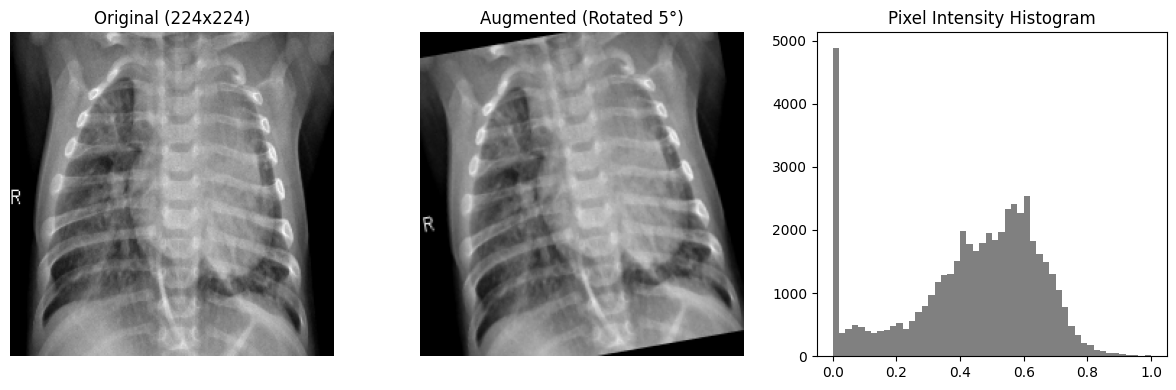

In [17]:
# 3. EDA (Visualization)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_resized, cmap='gray')
axes[0].set_title("Original (224x224)")
axes[0].axis('off')

axes[1].imshow(img_augmented, cmap='gray')
axes[1].set_title("Augmented (Rotated 5°)")
axes[1].axis('off')

axes[2].hist(img_normalized.ravel(), bins=50, color='gray')
axes[2].set_title("Pixel Intensity Histogram")

plt.tight_layout()
plt.show()

PART D: Signal Data (MIT-BIH Arrhythmia Database - ECG)

In [19]:
# 1. Data Acquisition
record = wfdb.rdrecord('100', sampto=2000, pn_dir='mitdb')
ecg_signal = record.p_signal[:, 0] # First channel
fs = record.fs # Sampling frequency (360 Hz)

In [20]:
# 2. Noise Removal (Bandpass Filter)
# Removes baseline wander and high-frequency noise
def butter_bandpass_filter(data, lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

filtered_ecg = butter_bandpass_filter(ecg_signal, lowcut=0.5, highcut=40.0, fs=fs)


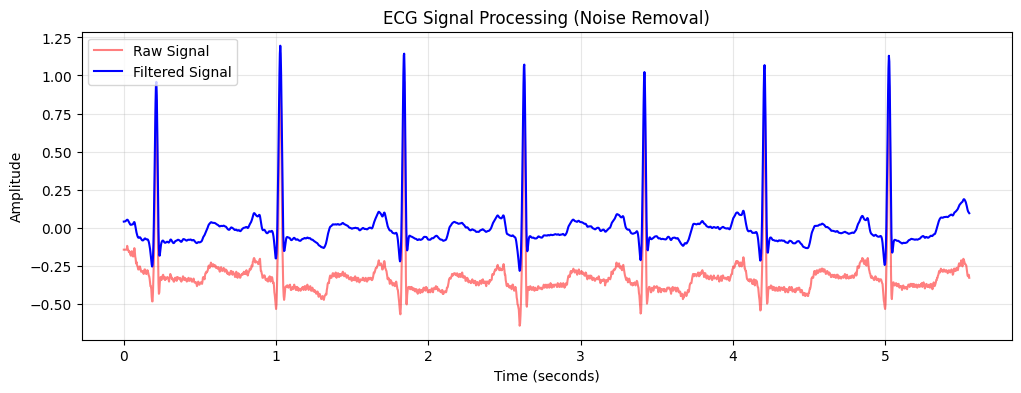

In [21]:
# 3. EDA (Visualization)
time_axis = np.arange(len(ecg_signal)) / fs

plt.figure(figsize=(12, 4))
plt.plot(time_axis, ecg_signal, label="Raw Signal", alpha=0.5, color='red')
plt.plot(time_axis, filtered_ecg, label="Filtered Signal", color='blue', linewidth=1.5)
plt.title("ECG Signal Processing (Noise Removal)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()